In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import r2_score,accuracy_score,classification_report,confusion_matrix

In [2]:
df = pd.read_csv('../data/Data.csv')
df

,Description,Name,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Country,Afghanistan,1850,AFG,3752993.0,NaN,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.436,0.629,NaN,NaN
1,Country,Afghanistan,1851,AFG,3767956.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.156,0.0,0.0,0.0,0.0,7.500,0.633,NaN,NaN
2,Country,Afghanistan,1852,AFG,3783940.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.155,0.0,0.0,0.0,0.0,7.560,0.637,NaN,NaN
3,Country,Afghanistan,1853,AFG,3800954.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.155,0.0,0.0,0.0,0.0,7.620,0.641,NaN,NaN
4,Country,Afghanistan,1854,AFG,3818038.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.155,0.0,0.0,0.0,0.0,7.678,0.644,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43741,International_Sector,International transport,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43742,International_Sector,International transport,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43743,International_Sector,International transport,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43744,International_Sector,International transport,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [3]:
df.head(10)

,Description,Name,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Country,Afghanistan,1850,AFG,3752993.0,NaN,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.436,0.629,NaN,NaN
1,Country,Afghanistan,1851,AFG,3767956.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.156,0.0,0.0,0.0,0.0,7.500,0.633,NaN,NaN
2,Country,Afghanistan,1852,AFG,3783940.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.155,0.0,0.0,0.0,0.0,7.560,0.637,NaN,NaN
3,Country,Afghanistan,1853,AFG,3800954.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.155,0.0,0.0,0.0,0.0,7.620,0.641,NaN,NaN
4,Country,Afghanistan,1854,AFG,3818038.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.155,0.0,0.0,0.0,0.0,7.678,0.644,NaN,NaN
5,Country,Afghanistan,1855,AFG,3835192.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.155,0.0,0.0,0.0,0.0,7.735,0.648,NaN,NaN
6,Country,Afghanistan,1856,AFG,3852417.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.154,0.0,0.0,0.0,0.0,7.790,0.652,NaN,NaN
7,Country,Afghanistan,1857,AFG,3869714.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.154,0.0,0.0,0.0,0.0,7.845,0.656,NaN,NaN
8,Country,Afghanistan,1858,AFG,3887081.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.154,0.0,0.0,0.0,0.0,7.899,0.660,NaN,NaN
9,Country,Afghanistan,1859,AFG,3904521.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.154,0.0,0.0,0.0,0.0,7.950,0.663,NaN,NaN


In [4]:
df.tail(10)

,Description,Name,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
43736,International_Sector,International transport,2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43737,International_Sector,International transport,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43738,International_Sector,International transport,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43739,International_Sector,International transport,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43740,International_Sector,International transport,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43741,International_Sector,International transport,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43742,International_Sector,International transport,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43743,International_Sector,International transport,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43744,International_Sector,International transport,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
43745,International_Sector,International transport,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43746 entries, 0 to 43745
Data columns (total 80 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Description                                43746 non-null  str    
 1   Name                                       43746 non-null  str    
 2   year                                       43746 non-null  int64  
 3   iso_code                                   37921 non-null  str    
 4   population                                 37965 non-null  float64
 5   gdp                                        14989 non-null  float64
 6   cement_co2                                 23612 non-null  float64
 7   cement_co2_per_capita                      22715 non-null  float64
 8   co2                                        27059 non-null  float64
 9   co2_growth_abs                             24987 non-null  float64
 10  co2_growth_prct                  

In [6]:
df.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,43746.000000,3.796500e+04,1.498900e+04,23612.000000,22715.000000,27059.000000,24987.000000,24668.000000,23585.000000,23285.000000,...,2108.000000,40828.000000,38060.000000,40828.000000,40828.000000,38060.000000,37410.000000,37236.000000,4535.000000,4535.000000
mean,1936.641727,5.739481e+07,3.351123e+11,9.495191,0.065905,446.602788,6.664167,44.661670,535.581202,7.214604,...,7.512655,2.278887,0.003026,0.007703,0.011070,0.000509,488.542225,316.133529,-7.232399,20.524440
std,50.243385,3.301779e+08,3.112988e+12,69.088018,0.125343,2015.844863,64.737394,1775.507928,2202.219657,99.347980,...,17.671054,9.333870,0.016519,0.043784,0.062028,0.003043,2392.579910,1839.602293,250.640012,52.744956
min,1850.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1977.750000,-100.000000,-99.693000,-2325.500000,...,0.000000,-0.810000,-0.001000,0.000000,-0.001000,0.000000,-14.961000,0.000000,-2195.952000,-98.849000
25%,1893.000000,3.324760e+05,7.955879e+09,0.000000,0.000000,0.487000,-0.011000,-1.280250,6.418000,-0.908000,...,0.204750,0.004000,0.000000,0.000000,0.000000,0.000000,1.835000,0.235000,-3.179500,-6.168000
50%,1937.000000,2.432030e+06,2.754978e+10,0.033000,0.006000,5.522000,0.051000,3.919500,27.691000,0.078000,...,0.838000,0.079000,0.000000,0.000000,0.000000,0.000000,15.007500,2.371000,1.518000,8.701000
75%,1980.000000,9.670886e+06,1.248960e+11,0.895250,0.090000,60.021000,1.131500,11.035750,123.959000,2.620000,...,3.211000,0.364000,0.001000,0.001000,0.001000,0.000000,78.242750,29.337500,9.153500,32.666000
max,2023.000000,8.091735e+09,1.301130e+14,1696.308000,2.484000,37791.570000,1865.208000,180870.000000,41416.480000,2340.184000,...,100.000000,100.000000,0.422000,1.161000,1.668000,0.085000,53816.852000,44114.785000,1798.999000,568.635000


In [7]:
df.value_counts()

Description  Name           year  iso_code  population   gdp           cement_co2  cement_co2_per_capita  co2       co2_growth_abs  co2_growth_prct  co2_including_luc  co2_including_luc_growth_abs  co2_including_luc_growth_prct  co2_including_luc_per_capita  co2_including_luc_per_gdp  co2_including_luc_per_unit_energy  co2_per_capita  co2_per_gdp  co2_per_unit_energy  coal_co2  coal_co2_per_capita  consumption_co2  consumption_co2_per_capita  consumption_co2_per_gdp  cumulative_cement_co2  cumulative_co2  cumulative_co2_including_luc  cumulative_coal_co2  cumulative_flaring_co2  cumulative_gas_co2  cumulative_luc_co2  cumulative_oil_co2  cumulative_other_co2  energy_per_capita  energy_per_gdp  flaring_co2  flaring_co2_per_capita  gas_co2   gas_co2_per_capita  ghg_excluding_lucf_per_capita  ghg_per_capita  land_use_change_co2  land_use_change_co2_per_capita  methane  methane_per_capita  nitrous_oxide  nitrous_oxide_per_capita  oil_co2   oil_co2_per_capita  other_co2_per_capita  other_in

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Description                        0
Name                               0
year                               0
iso_code                        5825
population                      5781
                               ...  
temperature_change_from_n2o     5686
total_ghg                       6336
total_ghg_excluding_lucf        6510
trade_co2                      39211
trade_co2_share                39211
Length: 80, dtype: int64

In [10]:
important_cols = ['Name', 'year', 'population', 'co2', 'gdp']
df_clean = df.dropna(subset=important_cols)
print(df_clean.shape)

(14459, 80)


In [11]:
df_clean.isnull().sum()

Description                        0
Name                               0
year                               0
iso_code                          20
population                         0
                               ...  
temperature_change_from_n2o       50
total_ghg                         33
total_ghg_excluding_lucf         104
trade_co2                      10544
trade_co2_share                10544
Length: 80, dtype: int64

In [12]:
df_clean.columns.tolist()

['Description',
 'Name',
 'year',
 'iso_code',
 'population',
 'gdp',
 'cement_co2',
 'cement_co2_per_capita',
 'co2',
 'co2_growth_abs',
 'co2_growth_prct',
 'co2_including_luc',
 'co2_including_luc_growth_abs',
 'co2_including_luc_growth_prct',
 'co2_including_luc_per_capita',
 'co2_including_luc_per_gdp',
 'co2_including_luc_per_unit_energy',
 'co2_per_capita',
 'co2_per_gdp',
 'co2_per_unit_energy',
 'coal_co2',
 'coal_co2_per_capita',
 'consumption_co2',
 'consumption_co2_per_capita',
 'consumption_co2_per_gdp',
 'cumulative_cement_co2',
 'cumulative_co2',
 'cumulative_co2_including_luc',
 'cumulative_coal_co2',
 'cumulative_flaring_co2',
 'cumulative_gas_co2',
 'cumulative_luc_co2',
 'cumulative_oil_co2',
 'cumulative_other_co2',
 'energy_per_capita',
 'energy_per_gdp',
 'flaring_co2',
 'flaring_co2_per_capita',
 'gas_co2',
 'gas_co2_per_capita',
 'ghg_excluding_lucf_per_capita',
 'ghg_per_capita',
 'land_use_change_co2',
 'land_use_change_co2_per_capita',
 'methane',
 'methane_p

In [13]:
df_clean.duplicated().sum()

np.int64(0)

In [14]:
df_clean.dtypes

Description                        str
Name                               str
year                             int64
iso_code                           str
population                     float64
                                ...   
temperature_change_from_n2o    float64
total_ghg                      float64
total_ghg_excluding_lucf       float64
trade_co2                      float64
trade_co2_share                float64
Length: 80, dtype: object

In [15]:
df_clean.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,14459.000000,1.445900e+04,1.445900e+04,12273.000000,12273.000000,14459.000000,14386.00000,14353.000000,14272.000000,14182.000000,...,1496.000000,14442.000000,14409.000000,14442.000000,14442.000000,14409.000000,14426.000000,14355.000000,3915.000000,3915.000000
mean,1970.421122,3.714900e+07,3.469670e+11,5.062751,0.097094,145.496455,2.89956,39.246478,206.553106,2.690742,...,2.941175,1.036260,0.001720,0.004566,0.006676,0.000243,260.963471,179.636973,0.045571,24.857533
std,38.853288,2.377657e+08,3.168896e+12,51.348723,0.141823,1100.345756,42.54385,1551.854940,1258.623035,60.414016,...,10.947475,4.649378,0.011617,0.031959,0.045481,0.002230,1606.032773,1289.356780,106.484725,54.883076
min,1850.000000,2.430400e+04,5.543200e+07,0.000000,0.000000,0.000000,-1977.75000,-100.000000,-99.693000,-2325.500000,...,0.000000,-0.206000,-0.001000,0.000000,-0.001000,0.000000,-1.874000,0.019000,-1532.080000,-98.849000
25%,1953.000000,2.719862e+06,8.875651e+09,0.015000,0.001000,1.373500,-0.06375,-1.906000,9.916500,-1.529750,...,0.184000,0.067000,0.000000,0.000000,0.000000,0.000000,17.048750,3.811000,-1.059000,-4.019500
50%,1978.000000,6.634949e+06,2.950042e+10,0.312000,0.042000,7.932000,0.09500,3.542000,33.008500,0.098000,...,0.463500,0.188000,0.000000,0.001000,0.001000,0.000000,46.677000,15.157000,1.816000,12.504000
75%,2001.000000,2.125284e+07,1.326455e+11,1.589000,0.139000,48.038500,1.20575,10.443000,96.791750,2.713750,...,1.589500,0.518000,0.001000,0.002000,0.003000,0.000000,132.732250,68.923500,8.886500,37.716000
max,2022.000000,8.021407e+09,1.301130e+14,1696.308000,1.413000,37293.836000,1865.20800,147561.031000,40936.484000,2027.913000,...,100.000000,100.000000,0.417000,1.143000,1.644000,0.084000,53327.215000,43746.762000,654.142000,568.635000


In [16]:
print(df_clean['Description'].value_counts())

Description
Country              14366
Special_Territory       73
Region                  20
Name: count, dtype: int64


In [17]:
df_clean = df_clean[df_clean['Description']=='Country']

In [18]:
df_clean.shape

(14366, 80)

In [19]:
df_clean['Description'].value_counts()

Description
Country    14366
Name: count, dtype: int64

<Axes: xlabel='co2'>

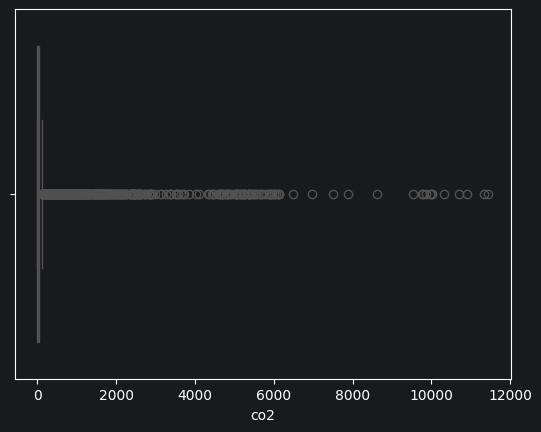

In [20]:
sns.boxplot(x = 'co2',data = df_clean)

In [21]:
df_clean['co2_log'] = np.log1p(df_clean['co2'])

<Axes: xlabel='co2_log'>

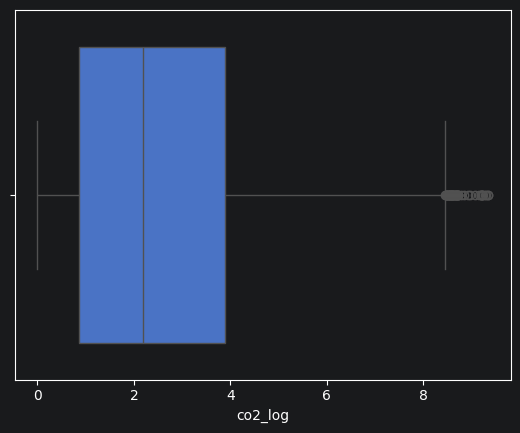

In [22]:
sns.boxplot(x = 'co2_log',data=df_clean)

In [23]:
# Top 10 CO2 emitting countries
latest = df_clean[df_clean['year'] == 2022]
top10 = df_clean.groupby('Name')['co2'].sum().sort_values(ascending=False).head(10)
print(top10)

Name
United States     426771.154
China             259082.560
Russia            113187.767
Germany            93746.628
United Kingdom     75882.489
Japan              67754.362
India              59791.267
France             39091.881
Canada             34597.099
Italy              25391.831
Name: co2, dtype: float64


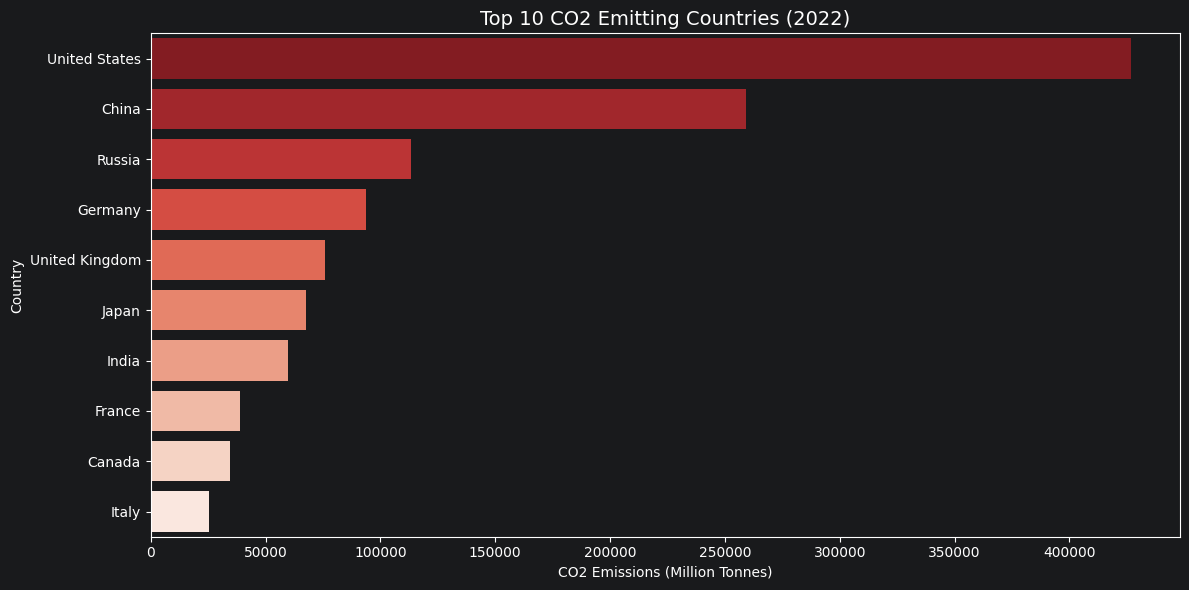

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette='Reds_r', legend=False)
plt.title('Top 10 CO2 Emitting Countries (2022)', fontsize=14)
plt.xlabel('CO2 Emissions (Million Tonnes)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

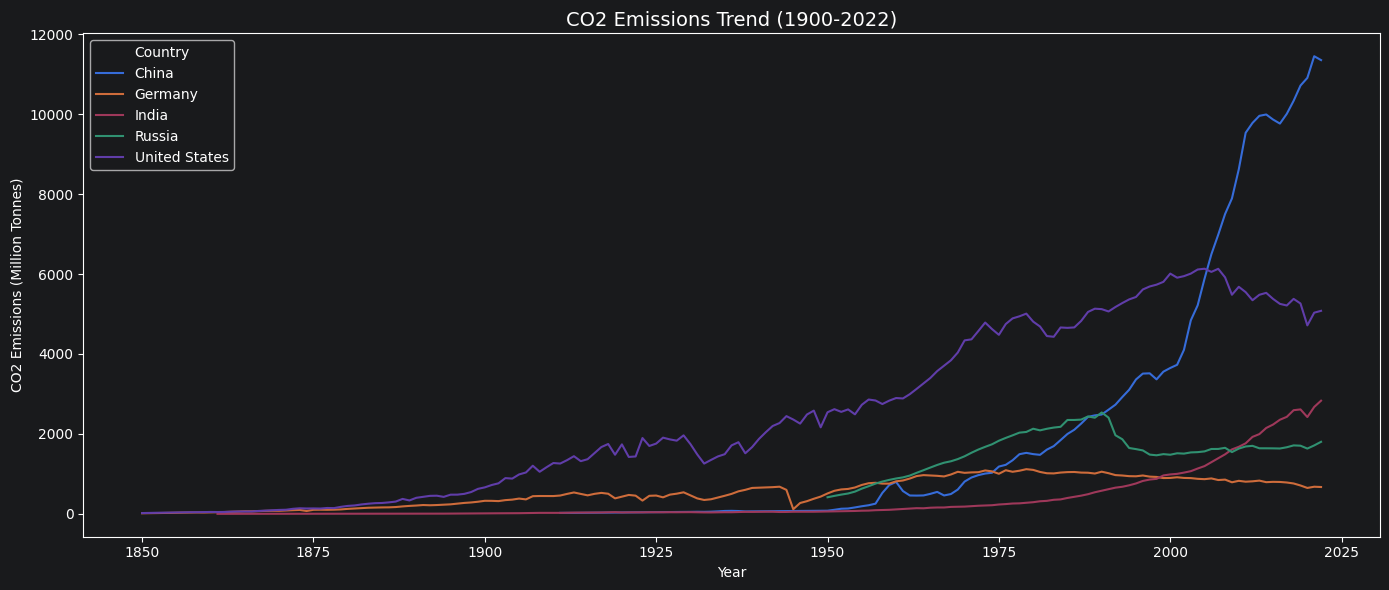

In [25]:
# Top 5 countries
top5_countries = ['United States', 'China', 'Russia', 'Germany', 'India']

df_top5 = df_clean[df_clean['Name'].isin(top5_countries)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_top5, x='year', y='co2', hue='Name')
plt.title('CO2 Emissions Trend (1900-2022)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (Million Tonnes)')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

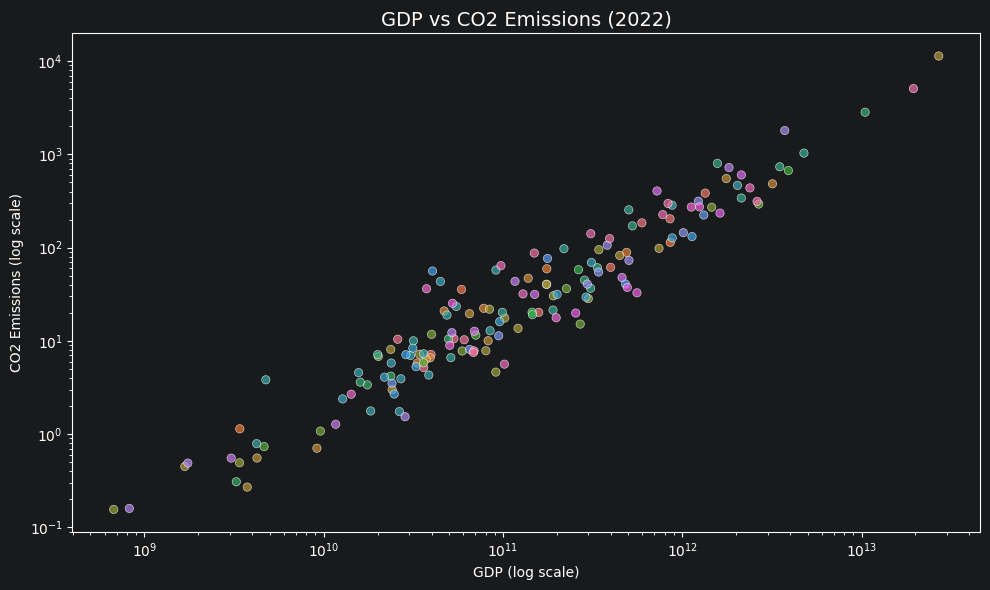

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean[df_clean['year']==2022],
                x='gdp', y='co2',
                hue='Name',
                legend=False,
                alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.title('GDP vs CO2 Emissions (2022)', fontsize=14)
plt.xlabel('GDP (log scale)')
plt.ylabel('CO2 Emissions (log scale)')
plt.tight_layout()
plt.show()

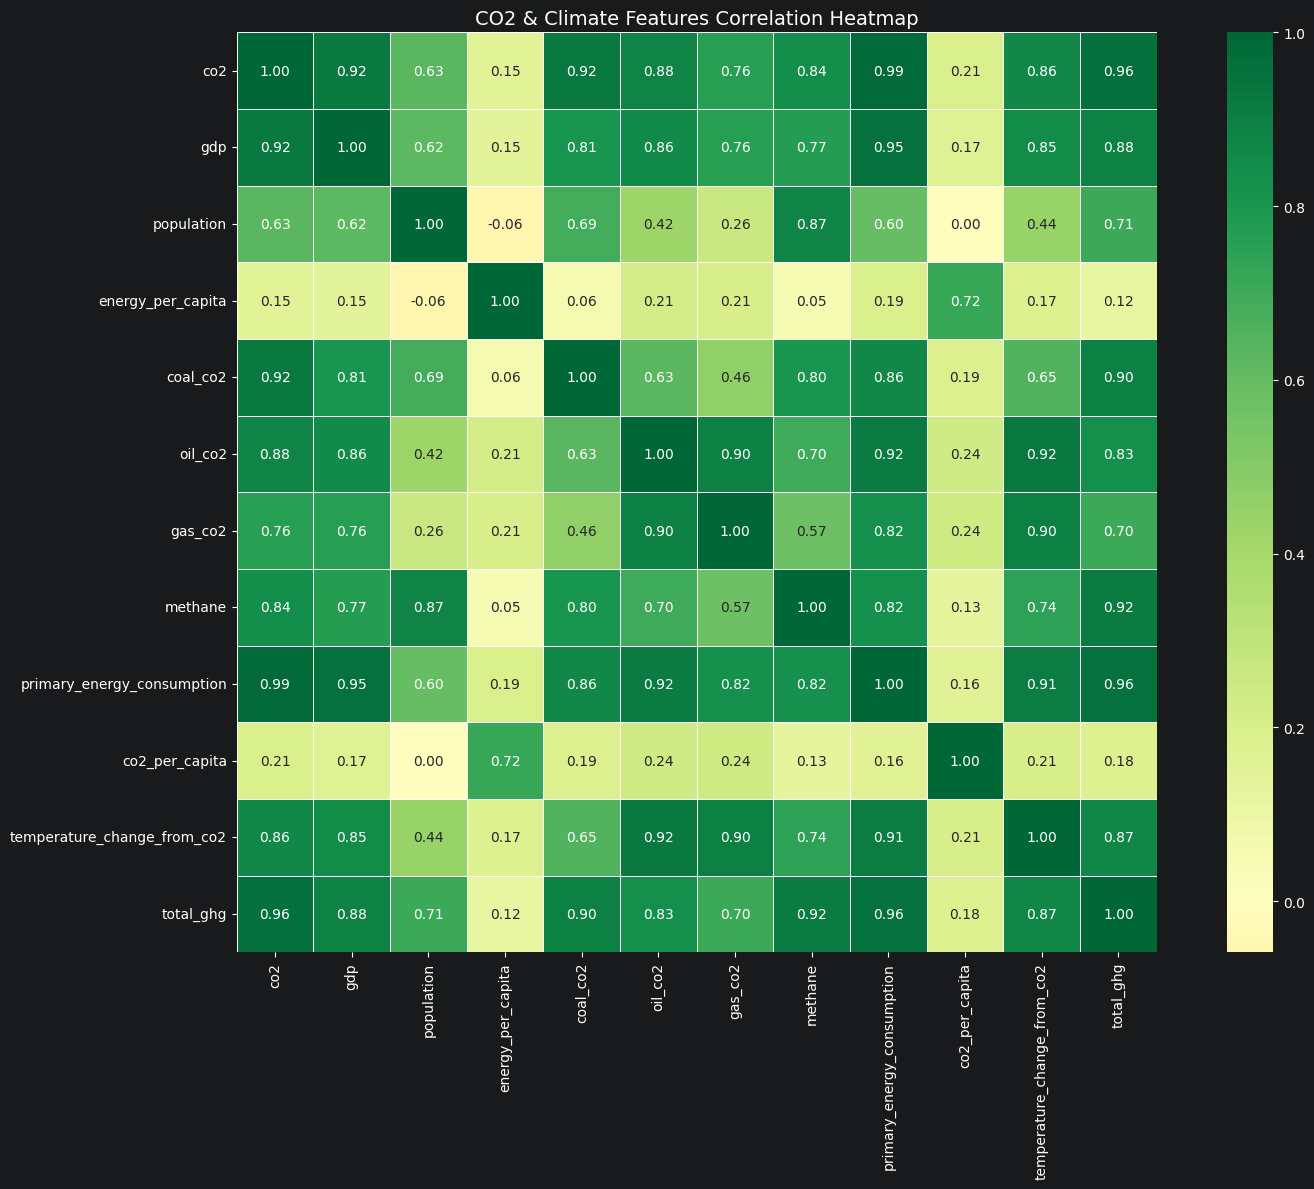

In [27]:
plt.figure(figsize=(16, 12))

corr_cols = ['co2', 'gdp', 'population', 'energy_per_capita',
             'coal_co2', 'oil_co2', 'gas_co2', 'methane',
             'primary_energy_consumption', 'co2_per_capita',
             'temperature_change_from_co2', 'total_ghg']

corr_matrix = df_clean[corr_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('CO2 & Climate Features Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
X = df_clean[['year', 'gdp', 'population', 'energy_per_capita',
              'coal_co2', 'oil_co2', 'gas_co2', 'methane',
              'primary_energy_consumption']]

y = df_clean['co2_log']
X

,year,gdp,population,energy_per_capita,coal_co2,oil_co2,gas_co2,methane,primary_energy_consumption
100,1950,9.421400e+09,7776182.0,NaN,0.021,0.063,0.0,8.101,NaN
101,1951,9.692280e+09,7879343.0,NaN,0.026,0.066,0.0,8.233,NaN
102,1952,1.001733e+10,7987783.0,NaN,0.032,0.060,0.0,8.373,NaN
103,1953,1.063052e+10,8096703.0,NaN,0.038,0.068,0.0,8.528,NaN
104,1954,1.086636e+10,8207953.0,NaN,0.043,0.064,0.0,8.691,NaN
...,...,...,...,...,...,...,...,...,...
34445,2018,2.678627e+10,15034457.0,3441.986,6.487,4.160,NaN,13.321,51.809
34446,2019,2.514642e+10,15271377.0,3003.655,6.013,3.778,NaN,12.957,46.120
34447,2020,2.317871e+10,15526888.0,2680.132,4.935,3.063,NaN,12.643,41.997
34448,2021,2.514009e+10,15797220.0,2635.154,5.938,3.735,NaN,13.046,42.145


In [29]:
X


,year,gdp,population,energy_per_capita,coal_co2,oil_co2,gas_co2,methane,primary_energy_consumption
100,1950,9.421400e+09,7776182.0,NaN,0.021,0.063,0.0,8.101,NaN
101,1951,9.692280e+09,7879343.0,NaN,0.026,0.066,0.0,8.233,NaN
102,1952,1.001733e+10,7987783.0,NaN,0.032,0.060,0.0,8.373,NaN
103,1953,1.063052e+10,8096703.0,NaN,0.038,0.068,0.0,8.528,NaN
104,1954,1.086636e+10,8207953.0,NaN,0.043,0.064,0.0,8.691,NaN
...,...,...,...,...,...,...,...,...,...
34445,2018,2.678627e+10,15034457.0,3441.986,6.487,4.160,NaN,13.321,51.809
34446,2019,2.514642e+10,15271377.0,3003.655,6.013,3.778,NaN,12.957,46.120
34447,2020,2.317871e+10,15526888.0,2680.132,4.935,3.063,NaN,12.643,41.997
34448,2021,2.514009e+10,15797220.0,2635.154,5.938,3.735,NaN,13.046,42.145


In [30]:
X.isnull().sum()

year                             0
gdp                              0
population                       0
energy_per_capita             6752
coal_co2                      2665
oil_co2                        560
gas_co2                       5062
methane                         33
primary_energy_consumption    6752
dtype: int64

In [31]:
X = X.fillna(X.median())

In [32]:
X.isnull().sum()

year                          0
gdp                           0
population                    0
energy_per_capita             0
coal_co2                      0
oil_co2                       0
gas_co2                       0
methane                       0
primary_energy_consumption    0
dtype: int64

In [33]:
X

,year,gdp,population,energy_per_capita,coal_co2,oil_co2,gas_co2,methane,primary_energy_consumption
100,1950,9.421400e+09,7776182.0,12650.042,0.021,0.063,0.0000,8.101,94.358
101,1951,9.692280e+09,7879343.0,12650.042,0.026,0.066,0.0000,8.233,94.358
102,1952,1.001733e+10,7987783.0,12650.042,0.032,0.060,0.0000,8.373,94.358
103,1953,1.063052e+10,8096703.0,12650.042,0.038,0.068,0.0000,8.528,94.358
104,1954,1.086636e+10,8207953.0,12650.042,0.043,0.064,0.0000,8.691,94.358
...,...,...,...,...,...,...,...,...,...
34445,2018,2.678627e+10,15034457.0,3441.986,6.487,4.160,0.9335,13.321,51.809
34446,2019,2.514642e+10,15271377.0,3003.655,6.013,3.778,0.9335,12.957,46.120
34447,2020,2.317871e+10,15526888.0,2680.132,4.935,3.063,0.9335,12.643,41.997
34448,2021,2.514009e+10,15797220.0,2635.154,5.938,3.735,0.9335,13.046,42.145


In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred_scaled = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred_scaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_scaled)

print("Linear Regression  Results:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Linear Regression  Results:
MSE  : 1.9804
RMSE : 1.4073
R²   : 0.4590


#Logistic Regression

In [36]:
df_clean['high_emitter'] = (df_clean['co2_per_capita'] >
                             df_clean['co2_per_capita'].median()).astype(int)

y_log = df_clean['high_emitter']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

print(df_clean['high_emitter'].value_counts())

high_emitter
0    7183
1    7183
Name: count, dtype: int64


In [37]:
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

# Model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train2_scaled, y_train2)
y_pred2 = log_model.predict(X_test2_scaled)

# Metrics
print("Logistic Regression Results:")
print(f"Accuracy : {accuracy_score(y_test2, y_pred2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test2, y_pred2))

Logistic Regression Results:
Accuracy : 0.8974

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.91      1475
           1       0.98      0.81      0.88      1399

    accuracy                           0.90      2874
   macro avg       0.91      0.90      0.90      2874
weighted avg       0.91      0.90      0.90      2874



In [38]:
# Training accuracy vs Testing accuracy compare karo
train_pred = log_model.predict(X_train2_scaled)
test_pred = log_model.predict(X_test2_scaled)

print(f"Training Accuracy : {accuracy_score(y_train2, train_pred):.4f}")
print(f"Testing Accuracy  : {accuracy_score(y_test2, test_pred):.4f}")
print(f"Difference        : {abs(accuracy_score(y_train2, train_pred) - accuracy_score(y_test2, test_pred)):.4f}")

Training Accuracy : 0.8878
Testing Accuracy  : 0.8974
Difference        : 0.0095


In [39]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train2, y_train2)
y_pred_dt = dt_model.predict(X_test2)

print("Decision Tree Results:")
print(f"Accuracy : {accuracy_score(y_test2, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test2, y_pred_dt))

Decision Tree Results:
Accuracy : 0.9770

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1475
           1       0.98      0.98      0.98      1399

    accuracy                           0.98      2874
   macro avg       0.98      0.98      0.98      2874
weighted avg       0.98      0.98      0.98      2874



In [40]:
train_pred_dt = dt_model.predict(X_train2)

print(f"Training Accuracy : {accuracy_score(y_train2, train_pred_dt):.4f}")
print(f"Testing Accuracy  : {accuracy_score(y_test2, y_pred_dt):.4f}")
print(f"Difference        : {abs(accuracy_score(y_train2, train_pred_dt) - accuracy_score(y_test2, y_pred_dt)):.4f}")

Training Accuracy : 1.0000
Testing Accuracy  : 0.9770
Difference        : 0.0230


In [41]:
dt_model_pruned = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=5
)
dt_model_pruned.fit(X_train2, y_train2)
y_pred_pruned = dt_model_pruned.predict(X_test2)
train_pred_pruned = dt_model_pruned.predict(X_train2)

print(f"Training Accuracy : {accuracy_score(y_train2, train_pred_pruned):.4f}")
print(f"Testing Accuracy  : {accuracy_score(y_test2, y_pred_pruned):.4f}")
print(f"Difference        : {abs(accuracy_score(y_train2, train_pred_pruned) - accuracy_score(y_test2, y_pred_pruned)):.4f}")

Training Accuracy : 0.9801
Testing Accuracy  : 0.9649
Difference        : 0.0152


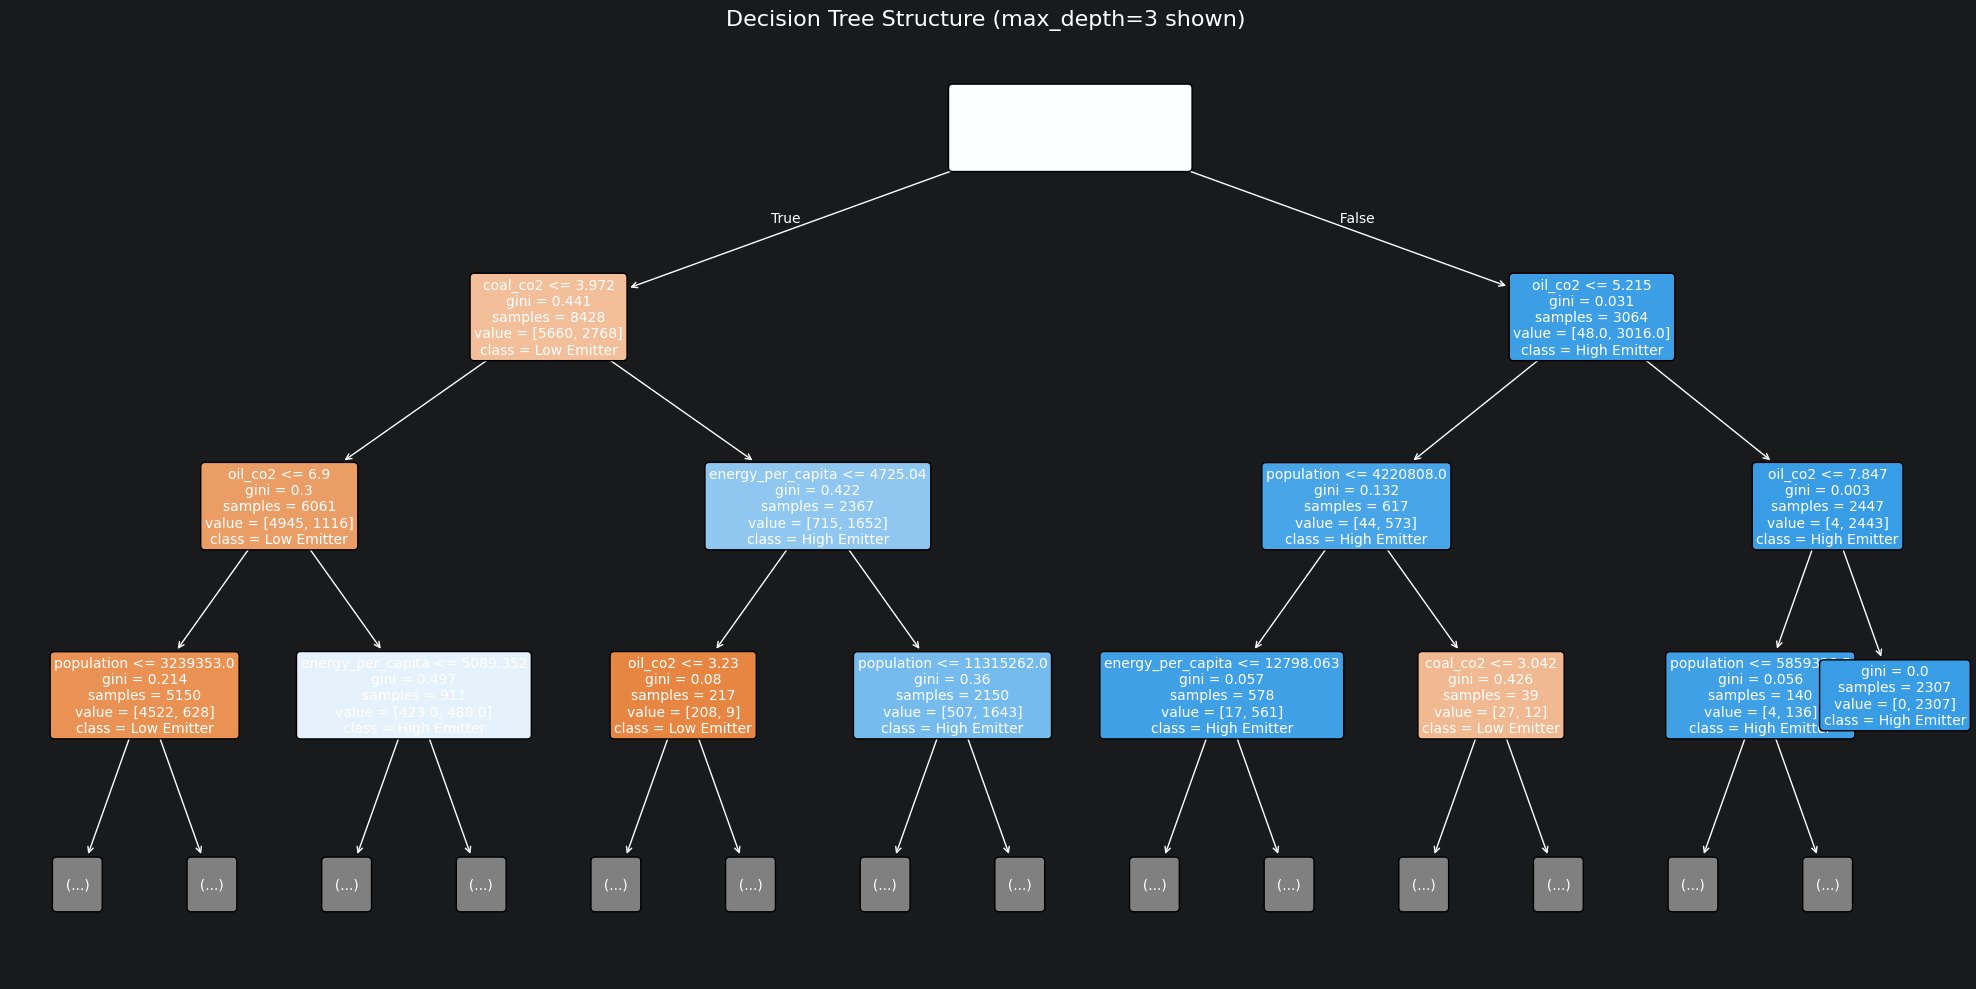

In [42]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model_pruned,
          feature_names=X.columns.tolist(),
          class_names=['Low Emitter', 'High Emitter'],
          filled=True,          # color se classes dikhao
          rounded=True,         # rounded boxes
          fontsize=10,
          max_depth=3)          # sirf top 3 levels dikhao (warna bahut bada hoga)

plt.title('Decision Tree Structure (max_depth=3 shown)', fontsize=16)
plt.tight_layout()
plt.show()

# Random Forest Classifier

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train2, y_train2)
y_pred_rf = rf_model.predict(X_test2)
train_pred_rf = rf_model.predict(X_train2)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['country_encoded'] = le.fit_transform(df_clean['Name'])

print("Random Forest Results:")
print(f"Training Accuracy : {accuracy_score(y_train2, train_pred_rf):.4f}")
print(f"Testing Accuracy  : {accuracy_score(y_test2, y_pred_rf):.4f}")
print(f"Difference        : {abs(accuracy_score(y_train2, train_pred_rf) - accuracy_score(y_test2, y_pred_rf)):.4f}")
print("\nClassification Report:")
print(classification_report(y_test2, y_pred_rf))

Random Forest Results:
Training Accuracy : 1.0000
Testing Accuracy  : 0.9868
Difference        : 0.0132

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1475
           1       0.99      0.99      0.99      1399

    accuracy                           0.99      2874
   macro avg       0.99      0.99      0.99      2874
weighted avg       0.99      0.99      0.99      2874



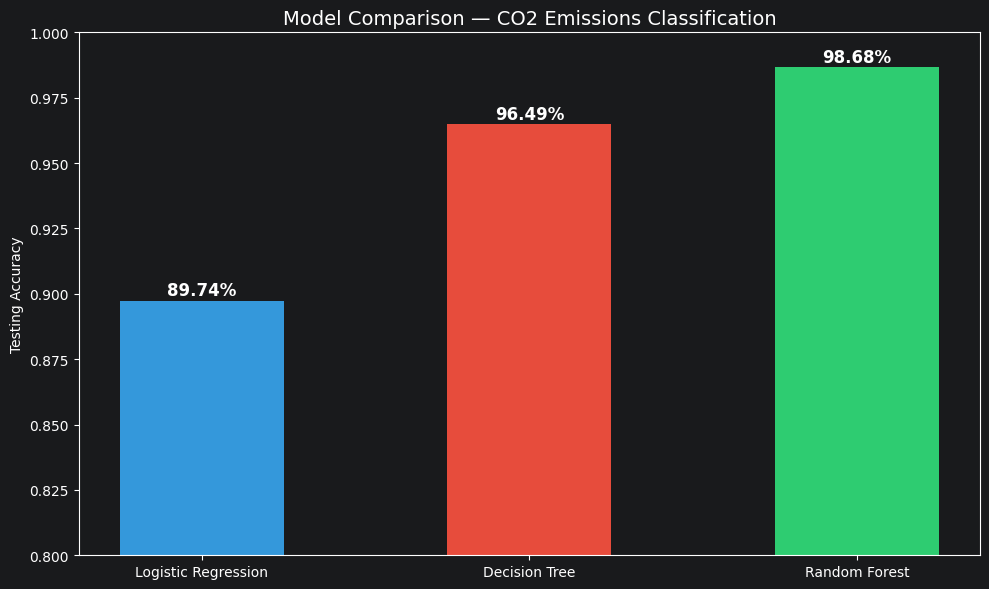

In [44]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [0.8974, 0.9649, 0.9868]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'], width=0.5)
plt.ylim(0.8, 1.0)
plt.title('Model Comparison — CO2 Emissions Classification', fontsize=14)
plt.ylabel('Testing Accuracy')

# Numbers dikhao bars pe
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{acc:.2%}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

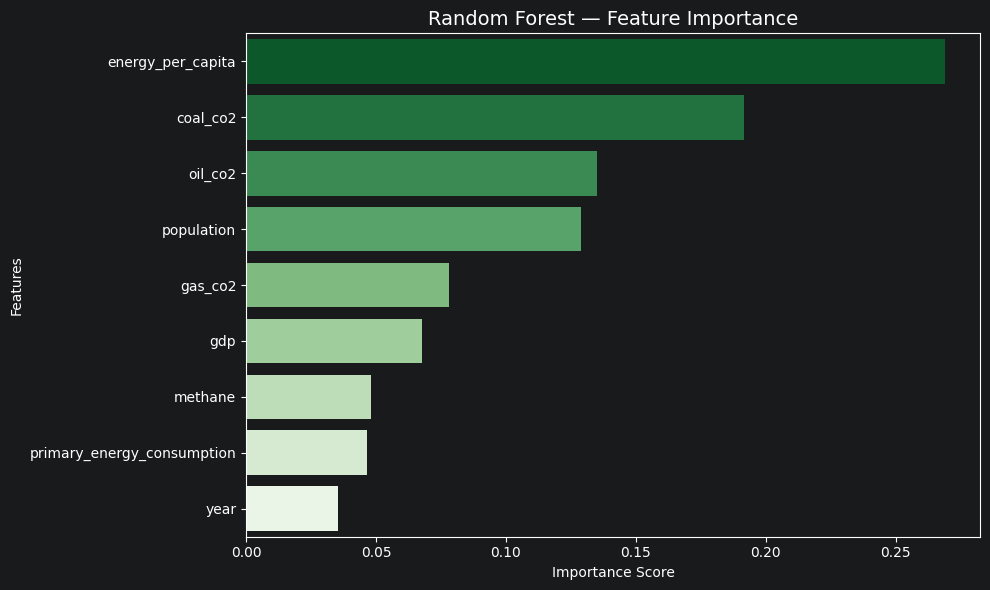

In [45]:
feat_importance = pd.Series(rf_model.feature_importances_,
                             index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index,
            hue=feat_importance.index, palette='Greens_r', legend=False)
plt.title('Random Forest — Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()